# Survival Analysis

Kaplan-Meier survival curves (overall + stratified) with log-rank tests,
and a Cox proportional hazards model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from churn.config import INTERIM_DIR
from churn.survival.prep import prepare_survival_data

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

subscriber_static = pd.read_parquet(INTERIM_DIR / "subscriber_static.parquet")

## 1. Survival data preparation

- **Duration**: tenure in days (`date_activation` → `churn_date` if churned, else censoring reference date)
- **Event**: 1 = churned (observed), 0 = censored (still active as of the reference date)
- **Censoring reference date**: max observed date across `churn_date`/`last_call_date` — not limited to the 7-month usage window, since this analysis doesn't use `monthly_agg`

In [2]:
survival_df = prepare_survival_data(subscriber_static)

Survival data prepared: 423766 subscribers (0 dropped for negative duration — activation after event/reference date)
Censoring reference date: 2025-03-19 23:59:59
Event rate: 8.56%
            duration          event
count  423766.000000  423766.000000
mean     1756.552928       0.085557
std      1955.826083       0.279709
min         0.000000       0.000000
25%       264.000000       0.000000
50%       971.000000       0.000000
75%      2515.000000       0.000000
max      8119.000000       1.000000


## 2. Kaplan-Meier — overall survival

inf


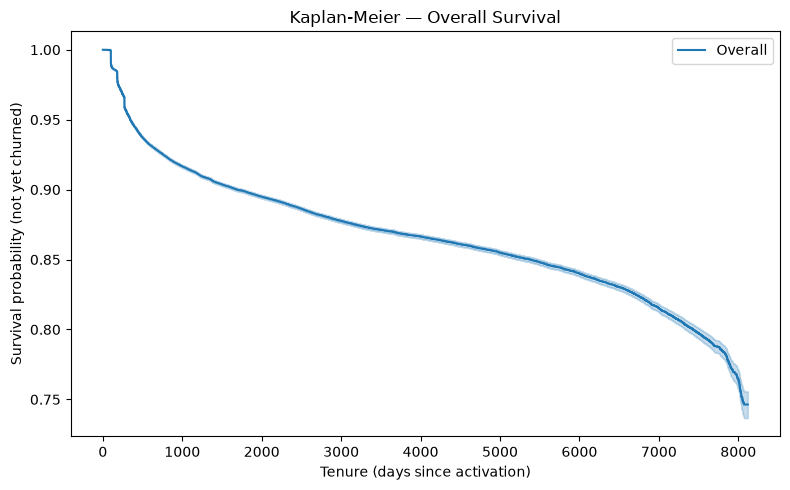

In [3]:
from churn.survival.kaplan_meier import fit_overall_km, plot_overall_km

kmf_overall = fit_overall_km(survival_df)
print(kmf_overall.median_survival_time_)

fig = plot_overall_km(kmf_overall)
save_fig(fig, "survival_01_overall_km")
plt.show()

- **The median survival time is not reached.** The survival probability remains well above 50% throughout the observed follow-up period (ending around 74%), meaning more than half of subscribers are still active at the end of observation. This is consistent with the relatively low overall churn rate (8.56%).

- **The survival curve shows a gradual decline rather than a sharp drop.**  This suggests that while some customers churn relatively early, most remain active for many years and churn accumulates progressively over time rather than occurring at one specific tenure.

## 3. Kaplan-Meier by group + log-rank tests

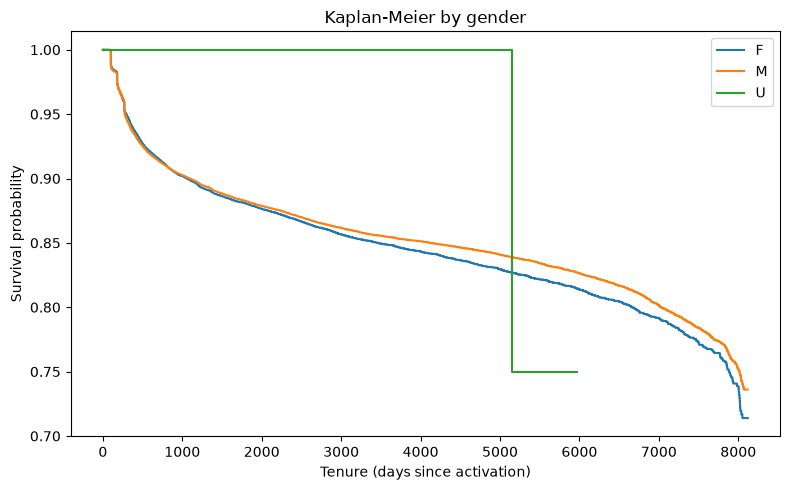


--- Log-rank test: gender ---
test statistic: 5.85, p-value: 0.05366


In [4]:
from churn.survival.kaplan_meier import fit_km_by_group, plot_km_by_group, run_logrank_test, add_age_bucket

fitters_gender = fit_km_by_group(survival_df, "gender")
fig = plot_km_by_group(fitters_gender, "Kaplan-Meier by gender", ci_show=False)
save_fig(fig, "survival_02_km_by_gender")
plt.show()
run_logrank_test(survival_df, "gender")

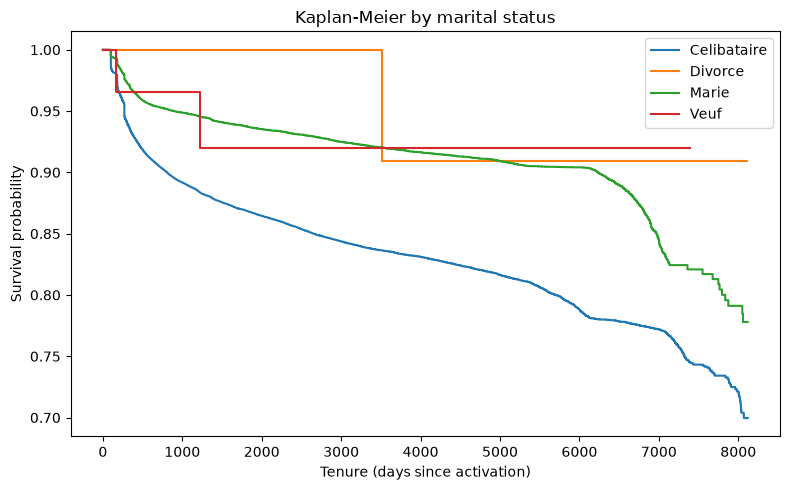


--- Log-rank test: marital_status ---
test statistic: 1689.97, p-value: 0


In [5]:
fitters_marital = fit_km_by_group(survival_df, "marital_status")
fig = plot_km_by_group(fitters_marital, "Kaplan-Meier by marital status", ci_show=False)
save_fig(fig, "survival_03_km_by_marital_status")
plt.show()
run_logrank_test(survival_df, "marital_status")

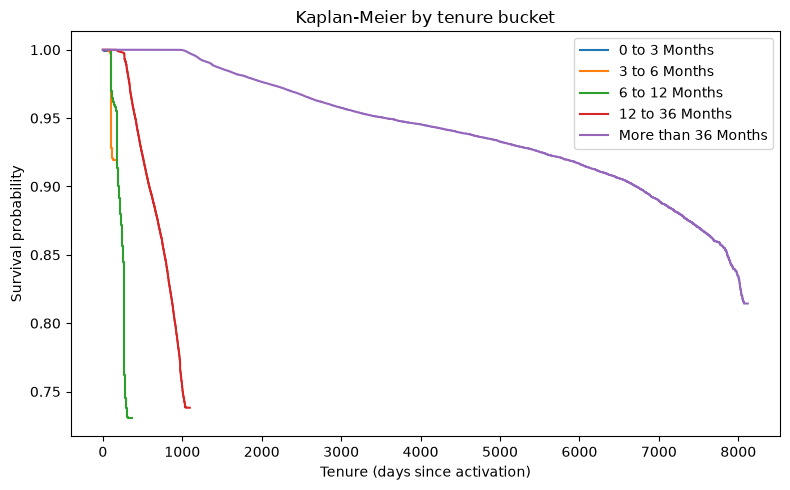


--- Log-rank test: classe_anciennete ---
test statistic: 86729.84, p-value: 0


In [6]:
fitters_tenure = fit_km_by_group(survival_df, "classe_anciennete", order=[
    "0 to 3 Months", "3 to 6 Months", "6 to 12 Months", "12 to 36 Months", "More than 36 Months"
])
fig = plot_km_by_group(fitters_tenure, "Kaplan-Meier by tenure bucket",ci_show=False)
save_fig(fig, "survival_04_km_by_tenure")
plt.show()
run_logrank_test(survival_df, "classe_anciennete")

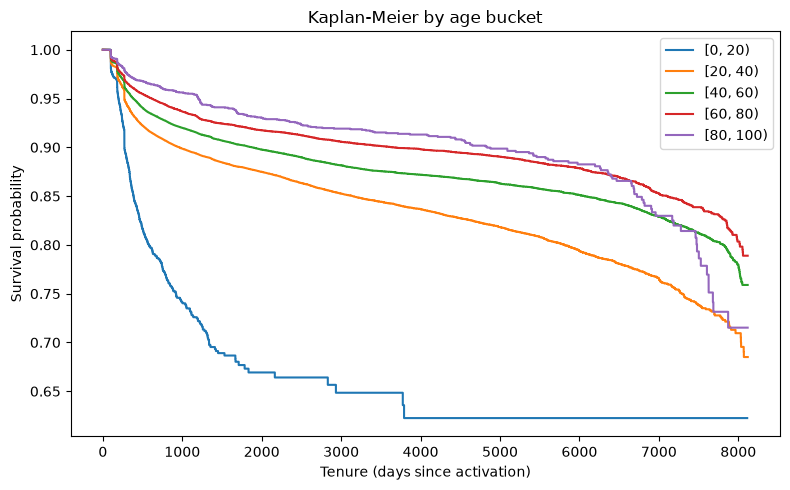


--- Log-rank test: age_bucket ---
test statistic: 2122.79, p-value: 0


In [7]:
survival_with_age = add_age_bucket(survival_df, bin_width=20)
fitters_age = fit_km_by_group(survival_with_age, "age_bucket")
fig = plot_km_by_group(fitters_age, "Kaplan-Meier by age bucket", ci_show=False)
save_fig(fig, "survival_05_km_by_age")
plt.show()
run_logrank_test(survival_with_age, "age_bucket")

**Interpretation:**

- **Gender:** Male and female survival curves almost overlap, indicating similar churn behavior. This agrees with the EDA, and the log-rank test (p = 0.054) shows the difference is not statistically significant. The "U" category is too small (n = 9) to interpret.

- **Marital status:** Single subscribers have lower survival than married subscribers, indicating higher churn risk. Divorced and widowed groups are too small for reliable conclusions. The log-rank test (p < 0.001) confirms significant differences between marital status groups.

- **Tenure bucket:** The Kaplan-Meier curves confirm the EDA results: subscribers with more than 36 months of tenure have the highest survival, while those with 6–12 months have the highest churn risk (log-rank p < 0.001).

- **Age bucket:** Younger subscribers have lower survival than older groups, consistent with the higher churn rate observed in the EDA. The log-rank test (p < 0.001) indicates these differences are statistically significant.

## 4. Cox Proportional Hazards model

Covariates: age, gender, marital_status, customer_language, classe_anciennete.
`contact_city` excluded (unresolved high-cardinality/messiness from EDA).

Dropped 20683 rows with missing age (Cox requires complete covariates)


c:\Users\tagho\churn-prediction\.venv\Lib\site-packages\lifelines\utils\__init__.py:1100: ConvergenceWarning: Column(s) ['gender_U', 'marital_status_Divorce', 'marital_status_Veuf'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


                                       hazard_ratio      coef              p  \
covariate                                                                      
classe_anciennete_More than 36 Months      0.000099 -9.215900  1.244541e-204   
classe_anciennete_12 to 36 Months          0.017128 -4.067066   2.080144e-42   
classe_anciennete_6 to 12 Months           0.205259 -1.583483   1.006543e-07   
gender_Missing                             0.317871 -1.146111  3.878523e-140   
customer_language_Arabe                    0.481039 -0.731807  2.622726e-100   
classe_anciennete_3 to 6 Months            0.501378 -0.690396   2.017517e-02   
gender_U                                   1.965227  0.675608   4.995113e-01   
marital_status_Divorce                     0.593530 -0.521667   6.020346e-01   
marital_status_Veuf                        1.461148  0.379223   5.919653e-01   
marital_status_Marie                       1.449146  0.370974   1.266052e-24   
customer_language_Français              

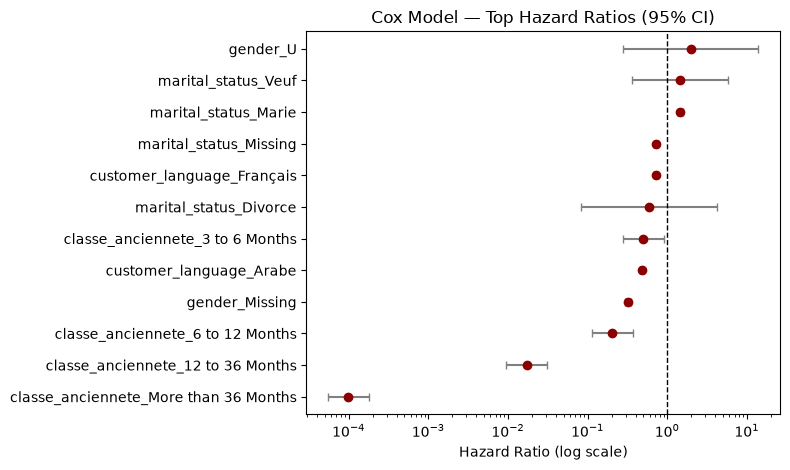

In [8]:
from churn.survival.cox_model import prepare_cox_data, fit_cox_model, get_top_hazard_ratios, plot_hazard_ratios

cox_df = prepare_cox_data(survival_df)
cph = fit_cox_model(cox_df)

top_hr = get_top_hazard_ratios(cph, top_n=12)
print(top_hr)

fig = plot_hazard_ratios(top_hr)
save_fig(fig, "survival_06_cox_hazard_ratios")
plt.show()

**Interpretation**

HR > 1 indicates a higher churn risk than the reference group, while HR < 1 indicates a lower churn risk.

- **Tenure is the strongest predictor of churn.** Subscribers with longer tenure have a much lower churn risk than the 0–3 month reference group, confirming the EDA and Kaplan-Meier results that long-term customers are more loyal.

- **Customer language also has an independent effect.** Arabic- and French-speaking subscribers have a lower churn risk than the reference group (Anglais).

- **Marital status.** While Kaplan-Meier suggests married subscribers have better survival, the Cox model (reference: `Celibataire`) shows `Marie` with a higher hazard (HR ≈ 1.45). This difference is explained by **tenure**: married subscribers are generally longer-tenured, and long tenure strongly reduces churn risk. Once tenure is accounted for, the apparent advantage disappears. Divorced and widowed groups are too small for reliable interpretation.

- **Missing demographic values remain informative.** Subscribers with missing gender or marital status have a lower churn risk, confirming the pattern observed in the EDA. These missing values should therefore be kept as their own category rather than imputed.